# Loading mock data with Argus



This notebook inspects the data loading procedure in Argus, making sure everything looks kosher. 

In [1]:
%load_ext autoreload
%autoreload 2

# 1. Get the data to pass to the filter 

In [6]:
import sys
import glob 
sys.path.append('../python/argus')
from data_loader import LoadWidebandPulsarData
import matplotlib.pyplot as plt 

[preProcess.C:158] Warning: PSR J0030+0451 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



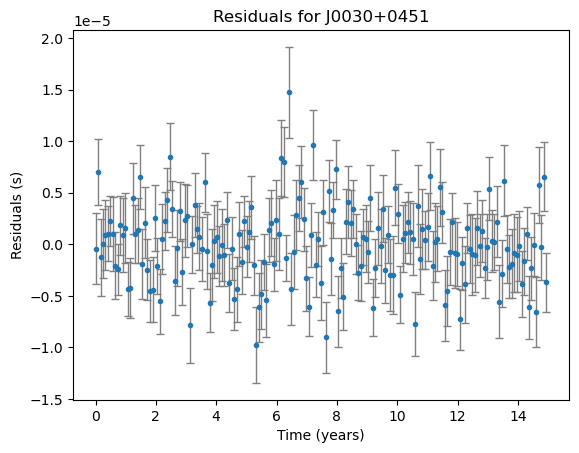

Pulsar J0030+0451
Cadence =  29.99753869537954 days
Total observation time =  14.947438857109038 years
[preProcess.C:158] Warning: PSR J0034-0534 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



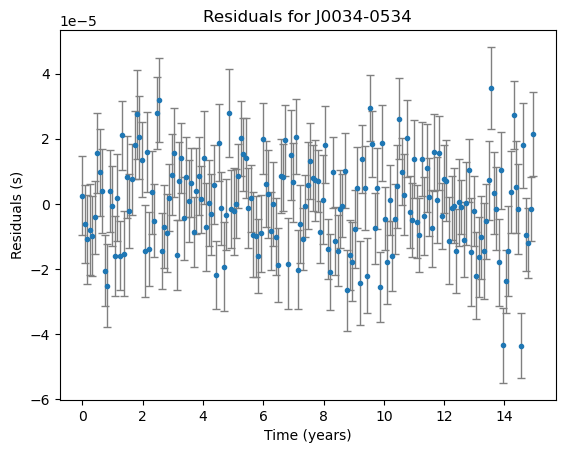

Pulsar J0034-0534
Cadence =  30.010274274809166 days
Total observation time =  14.953784854251248 years
[preProcess.C:158] Warning: PSR J0218+4232 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



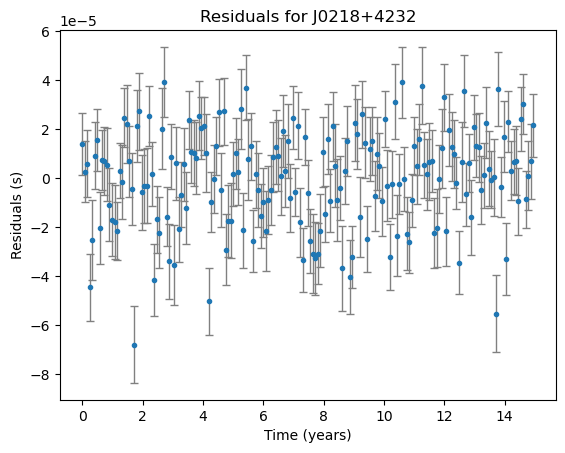

Pulsar J0218+4232
Cadence =  29.99126914699381 days
Total observation time =  14.944314811096163 years
[preProcess.C:158] Warning: PSR J0437-4715 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



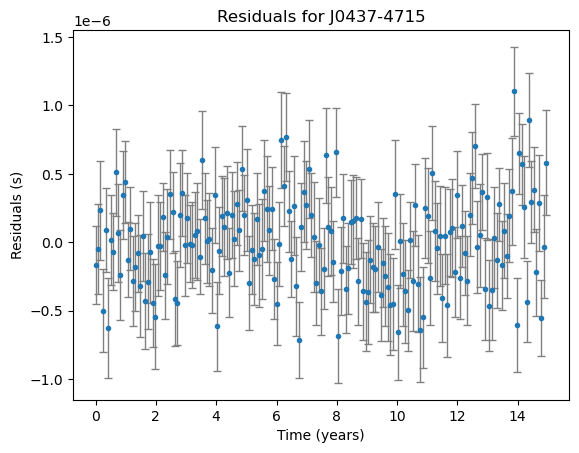

Pulsar J0437-4715
Cadence =  30.0072398096602 days
Total observation time =  14.952272814122262 years
[preProcess.C:158] Warning: PSR J0613-0200 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



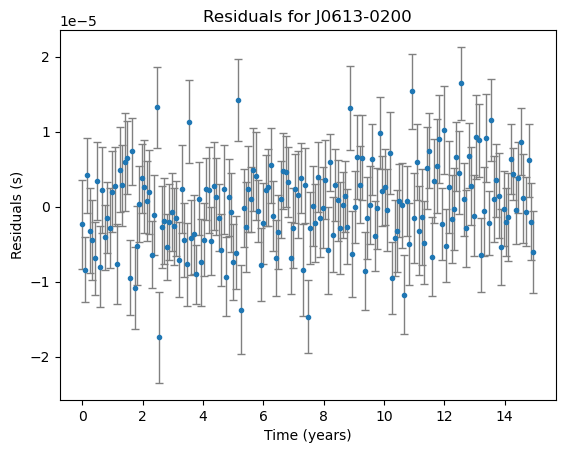

Pulsar J0613-0200
Cadence =  30.00755276570384 days
Total observation time =  14.952428756627238 years


In [39]:
import numpy as np
directory ="../data/IPTA_MockDataChallenge2/dataset_1b/" # https://github.com/ipta/mdc2/tree/master

# Get all .par and .tim files in the directory
par_files = sorted(glob.glob(directory + "*.par"))
tim_files = sorted(glob.glob(directory + "*.tim"))

assert len(par_files) == len(tim_files), "Mismatch between .par and .tim file counts."


#Load a couple of pulsars and plot the residuals to check everything looks reasonable one pulsar and check everything looks reasonable

for i in range(5):
    psr = LoadWidebandPulsarData.read_par_tim(par_files[i], tim_files[i])
    plt.figure()

    x = (psr.toas-psr.toas[0]) / (24*3600*365.25)
    plt.errorbar(
        x,          # X-values
        psr.residuals,     # Y-values
        yerr=psr.toaerrs,  # Size of the vertical error bars for each point
        fmt='.',           # Format: plot points ('.') without connecting lines.
        linestyle='none',  # Explicitly prevent lines connecting points.
        ecolor='gray',     # Optional: Set error bar color (e.g., gray is common)
        elinewidth=1,      # Optional: Set error bar line thickness
        capsize=3          # Optional: Adds caps to the error bars for clarity
    )
    
    plt.xlabel("Time (years)")
    plt.ylabel("Residuals (s)")
    plt.title(f"Residuals for {psr.name}")
    plt.show()

    dts = np.diff(psr.toas)
    max_dt = np.max(dts)
    min_dt = np.min(dts)
    mean_dt = np.mean(dts)
    Tobs = np.max(psr.toas) - np.min(psr.toas)
    print(f"Pulsar {psr.name}")
    print("Cadence = ",mean_dt/86400,"days")
    print("Total observation time = ",Tobs/(86400*365.25),"years")

    

Now lets load all the pulsars and do the preprocessing step

In [10]:
# # Get the data
print(f"Getting the data. Loading {len(par_files)} pulsars from {directory}")
pulsar_residuals, pulsar_metadata, pulsar_design_matrices = (
    LoadWidebandPulsarData.read_multiple_par_tim(par_files, tim_files)
)

Getting the data. Loading 33 pulsars from ../data/IPTA_MockDataChallenge2/dataset_1b/
[preProcess.C:158] Warning: PSR J0030+0451 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



J0030+0451 205.53069593846152 183
[preProcess.C:158] Warning: PSR J0034-0534 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



J0034-0534 532.7134293952242 183
[preProcess.C:158] Warning: PSR J0218+4232 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

J0218+4232 430.46105454575843 183
[preProcess.C:158] Warning: PSR J0437-4715 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

J0437-4715 173.68794573751967 183
[preProcess.C:158] Warning: PSR J0613-0200 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



J0613-0200 326.60056202349193 183
[preProcess.C:158] Warning: PSR J0621+1002 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

J0621+1002 34.65740662142043 183
[preProcess.C:158] Warning: PSR J0711-6830 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



J0711-6830 182.1172346472276 183
[preProcess.C:158] Warning: PSR J0751+1807 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



J0751+1807 287.4578539950941 183
[preProcess.C:158] Warning: PSR J0900-3144 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

J0900-3144 90.01184191936728 183
[preProcess.C:158] Warning: PSR J1012+5307 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

J1012+5307 190.26783444155498 183
[preProcess.C:158] Warning: PSR J1022+1001 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

J1022+1001 60.77944795669458 183
[preProcess.C:158] Warning: PSR J1024-0719 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://

J1603-7202 67.37658112877924 183
[preProcess.C:158] Warning: PSR J1614-2230 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

J1614-2230 317.37893706872126 183
[preProcess.C:158] Warning: PSR J1640+2224 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

J1640+2224 316.1239793318562 183
[preProcess.C:158] Warning: PSR J1643-1224 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

J1643-1224 216.37333714263337 183
[preProcess.C:158] Warning: PSR J1713+0747 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https:/

J1939+2134 641.9282245822369 183
[preProcess.C:158] Warning: PSR J1944+0907 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



J1944+0907 192.85651792018598 183
[preProcess.C:158] Warning: PSR J2010-1323 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

J2010-1323 191.45090909263828 183
[preProcess.C:158] Warning: PSR J2124-3358 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

J2124-3358 202.7938937460303 183
[preProcess.C:158] Warning: PSR J2129-5721 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

J2129-5721 268.3592272938659 183
[preProcess.C:158] Warning: PSR J2145-0750 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https:/

J2145-0750 62.29588783738885 183
[preProcess.C:158] Warning: PSR J2229+2643 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

J2229+2643 335.8162081968717 183
[preProcess.C:158] Warning: PSR J2317+1439 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

J2317+1439 290.25460366486976 183


Lets see what each of these look like.

In [16]:
pulsar_residuals

,toas,residuals_0,error_0,residuals_1,error_1,residuals_2,error_2,residuals_3,error_3,residuals_4,...,residuals_28,error_28,residuals_29,error_29,residuals_30,error_30,residuals_31,error_31,residuals_32,error_32
0,4.554371e+09,NaN,NaN,0.000003,0.000012,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4.554376e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.554409e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.554417e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4.554422e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6034,5.026286e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6035,5.026298e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6036,5.026302e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6037,5.026319e+09,-0.000004,0.000003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


6039 rows. This is Npsr (33) x Ntoas (183). Most columns are Nans because only one pulsar is observed at each TOA. We will clean this up later 

In [17]:
pulsar_metadata

,name,dim_M,RA,DEC,F0
0,J0030+0451,8,0.132894,0.084841,205.530696
1,J0034-0534,12,0.149941,-0.097335,532.713429
2,J0218+4232,12,0.602601,0.742431,430.461055
3,J0437-4715,18,1.209798,-0.824713,173.687946
4,J0613-0200,16,1.630718,-0.035136,326.600562
5,J0621+1002,13,1.664034,0.175302,34.657407
6,J0711-6830,7,1.884533,-1.195780,182.117235
7,J0751+1807,17,2.055791,0.316382,287.457854
8,J0900-3144,13,2.359391,-0.554001,90.011842
9,J1012+5307,15,2.672785,0.927072,190.267834


In [19]:
for array in pulsar_design_matrices:
    print(array.shape)


(183, 8)
(183, 12)
(183, 12)
(183, 18)
(183, 16)
(183, 13)
(183, 7)
(183, 17)
(183, 13)
(183, 15)
(183, 18)
(183, 8)
(183, 12)
(183, 14)
(183, 17)
(183, 14)
(183, 15)
(183, 17)
(183, 14)
(183, 17)
(183, 8)
(183, 8)
(183, 16)
(183, 17)
(183, 15)
(183, 8)
(183, 8)
(183, 8)
(183, 8)
(183, 13)
(183, 15)
(183, 12)
(183, 14)


These shapes look good. The nrows matches the number of times and the ncols matches the `M` column in the `pulsar_metadata` dataframe

### Preprocessing the data

We have a bunch of separate timeseries for each pulsar.

We want to bring these into a single data object that the Kalman filter can iterate through.

In [20]:
from gravitational_waves import hellings_downs

# Get the separation angles and compute HD correlation
ra = pulsar_metadata["RA"].to_numpy(dtype=float)
dec = pulsar_metadata["DEC"].to_numpy(dtype=float)
angular_separation_matrix = LoadWidebandPulsarData.pairwise_angular_separation(ra, dec)
hd_correlation_matrix = hellings_downs(angular_separation_matrix)

# Post-process the residuals
processed_pulsar_residuals = LoadWidebandPulsarData.post_process_residuals(pulsar_residuals)

print("Total length of the data is ", len(processed_pulsar_residuals))
print("Total number of pulsars is ", len(pulsar_metadata))

Total length of the data is  6039
Total number of pulsars is  33


Lets have a look at what these look like. 

In [23]:
Npsr = 5
hd_correlation_matrix[0:Npsr,0:Npsr]

array([[ 1.        ,  0.43799723,  0.04536893, -0.14450313, -0.15031912],
       [ 0.43799723,  1.        , -0.03641561, -0.1163107 , -0.15128409],
       [ 0.04536893, -0.03641561,  1.        , -0.13316351, -0.12771644],
       [-0.14450313, -0.1163107 , -0.13316351,  1.        , -0.00470765],
       [-0.15031912, -0.15128409, -0.12771644, -0.00470765,  1.        ]])

This looks reasonable. The diagonals are all one, and it is symmetric. 

In [40]:
processed_pulsar_residuals[0:Npsr,:]

array([[ 4.55437076e+09,  2.53170627e-06,  1.20851200e-05,
         1.00000000e+00],
       [ 4.55437632e+09, -2.34266825e-06,  5.93429000e-06,
         4.00000000e+00],
       [ 4.55440872e+09,  1.14138913e-06,  1.12219000e-06,
         1.40000000e+01],
       [ 4.55441723e+09,  3.53368951e-06,  2.69286000e-06,
         1.00000000e+01],
       [ 4.55442199e+09, -7.05108606e-06,  9.81196000e-06,
         1.30000000e+01]])

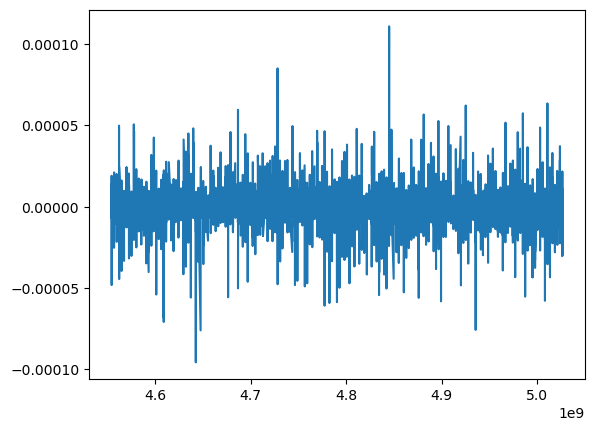

In [41]:

toas = processed_pulsar_residuals[:,0]
residuals = processed_pulsar_residuals[:,1]
residual_errors = processed_pulsar_residuals[:,2]
psr_index = processed_pulsar_residuals[:,3]

plt.figure()
plt.plot(toas,residuals)
# x = (psr.toas-psr.toas[0]) / (24*3600*365.25)
# plt.errorbar(
#     x,          # X-values
#     psr.residuals,     # Y-values
#     yerr=psr.toaerrs,  # Size of the vertical error bars for each point
#     fmt='.',           # Format: plot points ('.') without connecting lines.
#     linestyle='none',  # Explicitly prevent lines connecting points.
#     ecolor='gray',     # Optional: Set error bar color (e.g., gray is common)
#     elinewidth=1,      # Optional: Set error bar line thickness
#     capsize=3          # Optional: Adds caps to the error bars for clarity
# )